# Reinforcement Learning Individual Assignment
## Text Flappy Bird - SARSA($\lambda$) Agent with Eligibility Traces

In [1]:
import os, sys
import gymnasium as gym
import numpy as np
import pandas as pd
from collections import defaultdict
import matplotlib.pyplot as plt
from matplotlib.patches import Patch
from tqdm import tqdm
import time
import pickle
from pathlib import Path
from joblib import Parallel, delayed

import text_flappy_bird_gym

In [ ]:
TRAIN_AGENT = False
SAVE_AGENT = False

## 1. Environment Setup

We use the simple state variant `TextFlappyBird-v0` which returns `(x_distance, y_distance)` - the horizontal and vertical distance from the bird to the centre of the nearest pipe gap. The action space is `Discrete(2)`: **0 = idle** (do nothing), **1 = flap**.

In [3]:
# Initialise the environment (simple state: x_dist, y_dist)
env = gym.make('TextFlappyBird-v0', height=15, width=20, pipe_gap=4)

obs, info = env.reset()
print(f"Observation: {obs}")
print(f"Action space: {env.action_space}")  # Discrete(2)

Observation: (13, -1)
Action space: Discrete(2)


## 2. SARSA(λ) Agent

SARSA(λ) extends the one-step SARSA update with **eligibility traces**, which propagate the TD error backwards to all recently visited state-action pairs in a single pass.

**Key parameters:**
- $\alpha$ — step-size (learning rate)
- $\gamma$ — discount factor
- $\lambda$ — trace-decay parameter ($\lambda = 0$ gives one-step SARSA; $\lambda = 1$ gives Monte-Carlo-like behaviour)
- $\epsilon$ — exploration rate, decayed via GLIE: $\epsilon = 1/k$

**Per-step update (accumulating traces):**

$$\delta_t = R_{t+1} + \gamma \, Q(S', A') - Q(S, A)$$
$$E(S, A) \leftarrow E(S, A) + 1$$
$$\forall (s,a): \quad Q(s,a) \leftarrow Q(s,a) + \alpha \, \delta_t \, E(s,a)$$
$$\forall (s,a): \quad E(s,a) \leftarrow \gamma \, \lambda \, E(s,a)$$

In [4]:
class SarsaLambdaAgent:
    """SARSA(lambda) agent with accumulating eligibility traces for Text Flappy Bird."""

    def __init__(
        self,
        n_actions: int = 2,
        alpha: float = 0.1,
        gamma: float = 1.0,
        lambd: float = 0.8,
        min_epsilon: float = 0.01,
    ):
        self.n_actions = n_actions
        self.alpha = alpha
        self.gamma = gamma
        self.lambd = lambd
        self.min_epsilon = min_epsilon

        self.Q = defaultdict(float)   # (state, action) -> value
        self.epsilon = 1.0
        self.episode_count = 0

    # policy
    def get_action(self, state: tuple) -> int:
        """ε-greedy action selection."""
        if np.random.random() < self.epsilon:
            return np.random.randint(self.n_actions)
        q_values = [self.Q[(state, a)] for a in range(self.n_actions)]
        max_q = max(q_values)
        best = [a for a, q in enumerate(q_values) if q == max_q]
        return np.random.choice(best)

    def greedy_action(self, state: tuple) -> int:
        """Purely greedy action (for evaluation)."""
        q_values = [self.Q[(state, a)] for a in range(self.n_actions)]
        max_q = max(q_values)
        best = [a for a, q in enumerate(q_values) if q == max_q]
        return np.random.choice(best)

    # learning (one full episode)
    def run_episode(self, env) -> float:
        """
        Play one episode with SARSA(lambda) updates (accumulating traces).

        Returns the total undiscounted reward collected in the episode.
        """
        # Reset eligibility traces at the start of every episode
        E = defaultdict(float)

        obs, _ = env.reset()
        S = tuple(obs)
        A = self.get_action(S)
        total_reward = 0.0

        done = False
        while not done:
            obs_next, reward, done, _, info = env.step(A)
            total_reward += reward
            S_next = tuple(obs_next)

            if done:
                # Terminal step: Q(terminal, ·) = 0, so TD target is just R
                delta = reward - self.Q[(S, A)]
            else:
                A_next = self.get_action(S_next)
                delta = reward + self.gamma * self.Q[(S_next, A_next)] - self.Q[(S, A)]

            # Accumulating trace for the current (S, A)
            E[(S, A)] += 1.0

            # Update all Q-values that have non-zero traces
            for sa in list(E.keys()):
                self.Q[sa] += self.alpha * delta * E[sa]
                E[sa] *= self.gamma * self.lambd
                # Remove negligible traces to keep the dict small
                if E[sa] < 1e-6:
                    del E[sa]

            if not done:
                S = S_next
                A = A_next

        return total_reward

    # epsilon decay
    def decay_epsilon(self):
        """GLIE epsilon decay: epsilon = 1/k, floored at min_epsilon."""
        self.episode_count += 1
        self.epsilon = max(self.min_epsilon, 1.0 / self.episode_count)

## 3. Training Loop

We run thousands of episodes. In each episode we:
1. Run a full episode with online SARSA(λ) updates (eligibility traces propagate the TD error to all recently visited state-action pairs).
2. Decay $\epsilon \leftarrow 1/k$ (GLIE).

In [5]:
def train(env, agent, n_episodes: int = 50_000, log_every: int = 1000):
    """Train the SARSA(lambda) agent and return training statistics."""
    reward_history = []
    avg_rewards = []
    epsilon_history = []

    for k in tqdm(range(1, n_episodes + 1), desc="Training SARSA(\u03BB)"):
        total_reward = agent.run_episode(env)
        agent.decay_epsilon()

        reward_history.append(total_reward)
        epsilon_history.append(agent.epsilon)

        if k % log_every == 0:
            avg_r = np.mean(reward_history[-log_every:])
            avg_rewards.append(avg_r)
            print(f"Episode {k:>7d} | Avg reward (last {log_every}): {avg_r:7.2f} "
                  f"| \u03B5: {agent.epsilon:.5f} | Q-table size: {len(agent.Q)}")

    return reward_history, avg_rewards, epsilon_history

In [6]:
# Hyperparameters
ALPHA = 0.05        # step-size
GAMMA = 0.99        # discount factor (undiscounted, episodic)
LAMBDA = 0.9        # trace-decay
MIN_EPS = 0.05      # epsilon floor
N_EPISODES = 50_000 # number of training episodes

# Create agent
env = gym.make('TextFlappyBird-v0', height=15, width=20, pipe_gap=4)
agent = SarsaLambdaAgent(
    n_actions=env.action_space.n,
    alpha=ALPHA,
    gamma=GAMMA,
    lambd=LAMBDA,
    min_epsilon=MIN_EPS,
)

In [7]:
results_dir = Path.cwd().parent / 'results' / 'SARSA'
results_dir.mkdir(parents=True, exist_ok=True)
save_path = results_dir / 'sarsa_lambda_agent.pkl'

# Train or load agent
if TRAIN_AGENT:
    reward_history, avg_rewards, epsilon_history = train(env, agent, n_episodes=N_EPISODES)

    if SAVE_AGENT:
        with open(save_path, 'wb') as f:
            pickle.dump({
                'Q': dict(agent.Q),
                'epsilon': agent.epsilon,
                'episode_count': agent.episode_count,
                'alpha': agent.alpha,
                'gamma': agent.gamma,
                'lambd': agent.lambd,
            }, f)
        print(f"Agent saved to {save_path}")
else:
    if save_path.exists():
        with open(save_path, 'rb') as f:
            data = pickle.load(f)
            agent.Q = defaultdict(float, data['Q'])
            agent.epsilon = data['epsilon']
            agent.episode_count = data['episode_count']
            agent.alpha = data['alpha']
            agent.gamma = data['gamma']
            agent.lambd = data['lambd']
        print(f"Agent loaded from {save_path}")
    else:
        print(f"No saved agent found at {save_path}. Please train the agent first.")

Training SARSA(λ):   3%|▎         | 1389/50000 [00:00<00:28, 1715.76it/s]

Episode    1000 | Avg reward (last 1000):   15.29 | ε: 0.05000 | Q-table size: 455


Training SARSA(λ):   4%|▍         | 2161/50000 [00:01<00:39, 1213.71it/s]

Episode    2000 | Avg reward (last 1000):   17.88 | ε: 0.05000 | Q-table size: 493


Training SARSA(λ):   6%|▋         | 3185/50000 [00:02<00:54, 864.41it/s] 

...

Episode   48000 | Avg reward (last 1000):  212.38 | ε: 0.05000 | Q-table size: 546


Training SARSA(λ):  98%|█████████▊| 49023/50000 [09:42<00:11, 88.11it/s] 

Episode   49000 | Avg reward (last 1000):  192.63 | ε: 0.05000 | Q-table size: 546


Training SARSA(λ): 100%|██████████| 50000/50000 [09:55<00:00, 83.90it/s] 

Episode   50000 | Avg reward (last 1000):  200.36 | ε: 0.05000 | Q-table size: 546
Agent saved to c:\Users\adoni\Desktop\Reinforcement Learning\MDS-RL\individual assignment\results\SARSA\sarsa_lambda_agent.pkl


## 4. Training Curves

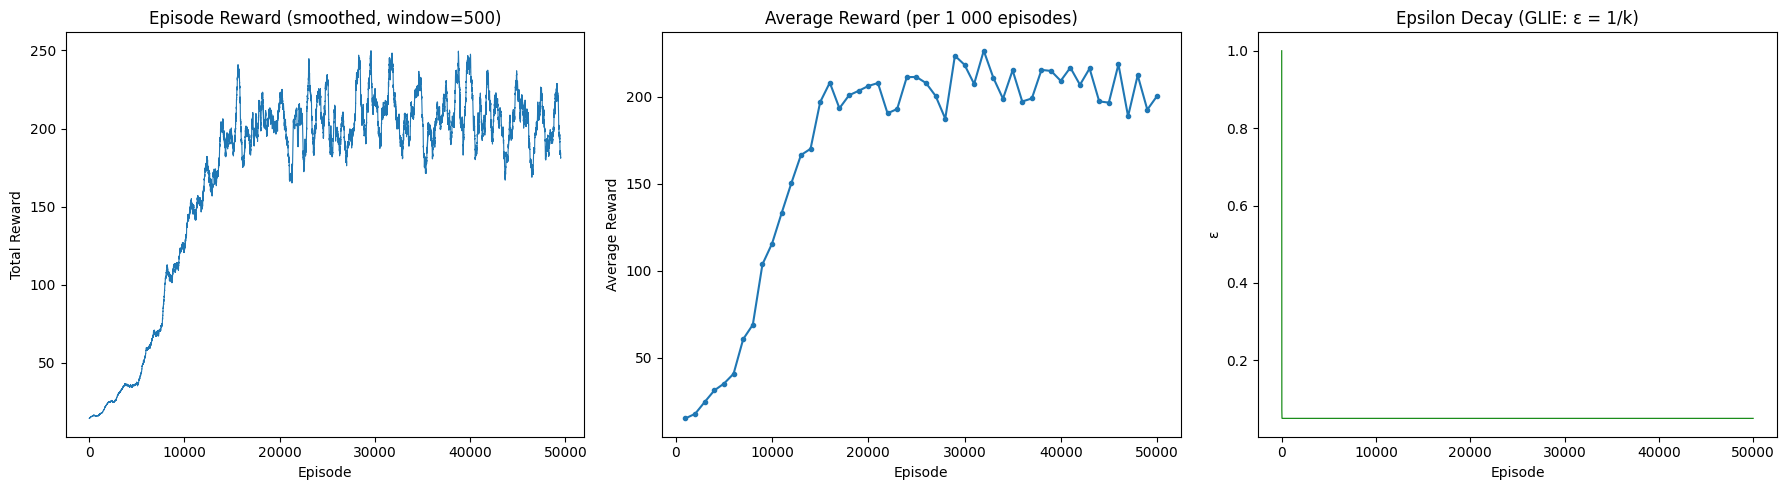

In [8]:
if TRAIN_AGENT:
    fig, axes = plt.subplots(1, 3, figsize=(18, 5))
    
    # Smoothed episode reward
    window = 500
    smoothed = np.convolve(reward_history, np.ones(window) / window, mode='valid')
    axes[0].plot(smoothed, linewidth=0.8)
    axes[0].set_xlabel('Episode')
    axes[0].set_ylabel('Total Reward')
    axes[0].set_title(f'Episode Reward (smoothed, window={window})')
    
    # Average reward per logging interval
    axes[1].plot(range(1000, N_EPISODES + 1, 1000), avg_rewards, marker='o', markersize=3)
    axes[1].set_xlabel('Episode')
    axes[1].set_ylabel('Average Reward')
    axes[1].set_title('Average Reward (per 1 000 episodes)')
    
    # Epsilon decay
    axes[2].plot(epsilon_history, linewidth=0.8, color='green')
    axes[2].set_xlabel('Episode')
    axes[2].set_ylabel('\u03B5')
    axes[2].set_title('Epsilon Decay (GLIE: \u03B5 = 1/k)')
    
    plt.tight_layout()
    plt.savefig(results_dir / 'training_curves.png', dpi=150, bbox_inches='tight')
    plt.show()

## 5. Evaluation (Greedy Policy)

Run the trained agent greedily ($\epsilon = 0$) over many episodes to measure its performance.

Evaluating: 100%|██████████| 1000/1000 [01:29<00:00, 11.18it/s]


Greedy evaluation over 1 000 episodes:
    Mean reward: 3798.66
    Std reward : 1782.87
    Max reward : 5000
    Min reward : 15


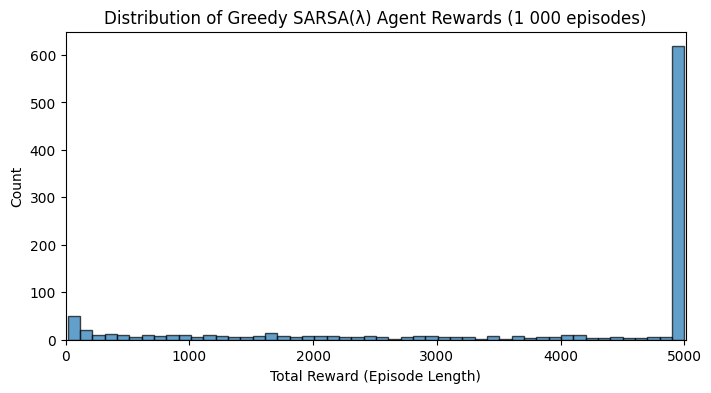

In [9]:
def evaluate(env, agent, n_episodes: int = 1000, max_steps: int = 5000):
    """Evaluate the agent using a purely greedy policy (no exploration)."""
    total_rewards = []
    for _ in tqdm(range(n_episodes), desc="Evaluating"):
        obs, _ = env.reset()
        state = tuple(obs)
        total_reward = 0.0
        done = False
        steps = 0
        while not done and steps < max_steps:
            action = agent.greedy_action(state)
            obs, reward, done, _, info = env.step(action)
            state = tuple(obs)
            total_reward += reward
            steps += 1
        total_rewards.append(total_reward)
    return total_rewards

eval_rewards = evaluate(env, agent, n_episodes=1000)
print(f"Greedy evaluation over 1 000 episodes:")
print(f"    Mean reward: {np.mean(eval_rewards):.2f}")
print(f"    Std reward : {np.std(eval_rewards):.2f}")
print(f"    Max reward : {np.max(eval_rewards):.0f}")
print(f"    Min reward : {np.min(eval_rewards):.0f}")

plt.figure(figsize=(8, 4))
plt.hist(eval_rewards, bins=50, edgecolor='black', alpha=0.7)
plt.xlim(0, max(eval_rewards) + 10)
plt.xlabel('Total Reward (Episode Length)')
plt.ylabel('Count')
plt.title('Distribution of Greedy SARSA(\u03BB) Agent Rewards (1 000 episodes)')
plt.savefig(results_dir / 'evaluation_histogram.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Hyperparameter Grid Search

We perform a grid search over the key SARSA(λ) hyperparameters to find the configuration that maximises mean greedy reward after a fixed training budget.

Each configuration is trained for $10,000$ episodes (a reduced budget for tractability) and evaluated greedily over $500$ episodes. Configurations are trained in parallel using joblib to speed up the search.

| Parameter | Values swept |
|---|---|
| `alpha` (step-size) | 0.05, 0.1, 0.2 |
| `lambd` (trace decay) | 0.6, 0.8, 0.9 |
| `min_epsilon` | 0.01, 0.05 |

In [10]:
# Grid definition
GS_EPISODES = 10_000
GS_EVAL_EPS = 500
GS_GAMMA    = 0.99

alphas       = [0.05, 0.1, 0.2]
lambds       = [0.6, 0.8, 0.9]
min_epsilons = [0.01, 0.05]

grid = []
for alpha in alphas:
    for lambd in lambds:
        for me in min_epsilons:
            grid.append((
                f"\u03b1={alpha} | \u03bb={lambd} | min_\u03b5={me}",
                dict(alpha=alpha, lambd=lambd, min_epsilon=me, gamma=GS_GAMMA),
            ))

print(f"Total configurations: {len(grid)}")
print(f"Total training episodes: {len(grid) * GS_EPISODES:,}")

Total configurations: 18
Total training episodes: 180,000


In [11]:
def _train_and_eval_sarsa(label, kwargs):
    """Train one SARSA config and return its evaluation result."""
    import text_flappy_bird_gym
    gs_env = gym.make('TextFlappyBird-v0', height=15, width=20, pipe_gap=4)
    gs_agent = SarsaLambdaAgent(n_actions=gs_env.action_space.n, **kwargs)

    for _ in range(1, GS_EPISODES + 1):
        gs_agent.run_episode(gs_env)
        gs_agent.decay_epsilon()

    rewards = evaluate(gs_env, gs_agent, n_episodes=GS_EVAL_EPS)
    return {"label": label, "kwargs": kwargs,
            "mean_reward": np.mean(rewards), "std_reward": np.std(rewards)}

gs_results = Parallel(n_jobs=-1, verbose=10)(
    delayed(_train_and_eval_sarsa)(label, kwargs)
    for label, kwargs in grid
)

gs_results.sort(key=lambda r: r["mean_reward"], reverse=True)
print("\nTop 10 configurations:")
print(f"{'Rank':<5} {'Mean Reward':>12} {'Std':>8}  Label")
print("-" * 75)
for i, r in enumerate(gs_results[:10], 1):
    print(f"{i:<5} {r['mean_reward']:>12.2f} {r['std_reward']:>8.2f}  {r['label']}")

[Parallel(n_jobs=-1)]: Using backend LokyBackend with 16 concurrent workers.
[Parallel(n_jobs=-1)]: Done   3 out of  18 | elapsed:   27.2s remaining:  2.3min
[Parallel(n_jobs=-1)]: Done   5 out of  18 | elapsed:   33.4s remaining:  1.5min
[Parallel(n_jobs=-1)]: Done   7 out of  18 | elapsed:   58.0s remaining:  1.5min
[Parallel(n_jobs=-1)]: Done   9 out of  18 | elapsed:  1.8min remaining:  1.8min
[Parallel(n_jobs=-1)]: Done  11 out of  18 | elapsed:  2.5min remaining:  1.6min
[Parallel(n_jobs=-1)]: Done  13 out of  18 | elapsed:  2.7min remaining:  1.0min
[Parallel(n_jobs=-1)]: Done  15 out of  18 | elapsed:  3.1min remaining:   37.7s



Top 10 configurations:
Rank   Mean Reward      Std  Label
---------------------------------------------------------------------------
1          5000.00     0.00  α=0.05 | λ=0.9 | min_ε=0.01
2          5000.00     0.00  α=0.1 | λ=0.8 | min_ε=0.05
3          5000.00     0.00  α=0.1 | λ=0.9 | min_ε=0.05
4          5000.00     0.00  α=0.2 | λ=0.8 | min_ε=0.05
5          5000.00     0.00  α=0.2 | λ=0.9 | min_ε=0.05
6          4830.25   738.31  α=0.1 | λ=0.6 | min_ε=0.05
7          2769.75  1836.93  α=0.05 | λ=0.9 | min_ε=0.05
8          2334.60  1667.95  α=0.2 | λ=0.9 | min_ε=0.01
9          1478.35  1347.20  α=0.2 | λ=0.8 | min_ε=0.01
10          530.68   525.37  α=0.2 | λ=0.6 | min_ε=0.05


[Parallel(n_jobs=-1)]: Done  18 out of  18 | elapsed:  3.7min finished


C:\Users\adoni\AppData\Local\Temp\ipykernel_23360\3693267198.py:23: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(lam_groups.values(), labels=lam_groups.keys(), patch_artist=True, boxprops=dict(facecolor="lightblue"), medianprops=dict(color="red", linewidth=2))


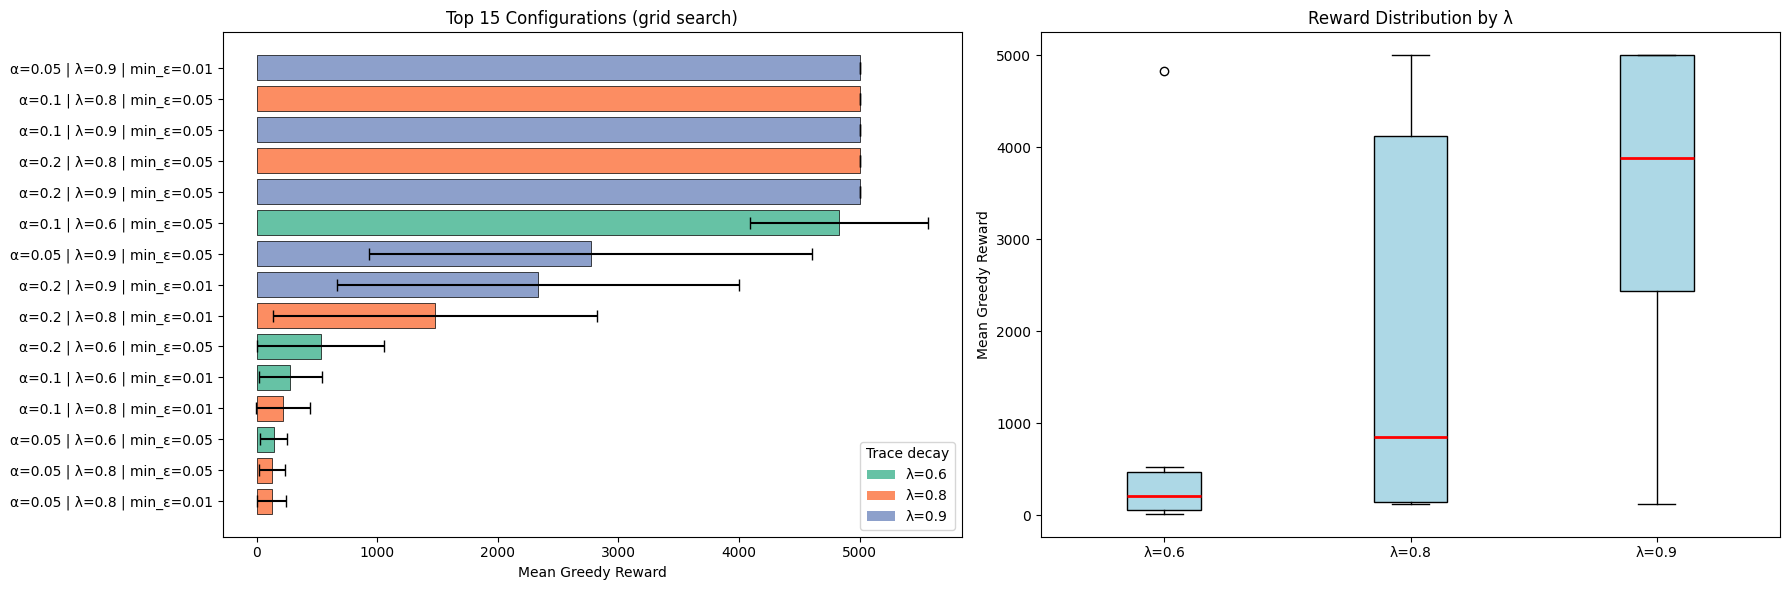


Best configuration found:
    α=0.05, λ=0.9, min_ε=0.01
    Mean reward: 5000.00 ± 0.00


In [12]:
df = pd.DataFrame(gs_results)

top_n = min(15, len(df))
df_top = df.head(top_n)

fig, axes = plt.subplots(1, 2, figsize=(18, 6))

unique_lambdas = sorted(set(r["kwargs"]["lambd"] for r in gs_results))
cmap = plt.cm.Set2
lam_colors = {l: cmap(i) for i, l in enumerate(unique_lambdas)}
bar_colors = [lam_colors[row["kwargs"]["lambd"]] for _, row in df_top.iterrows()]

axes[0].barh(df_top["label"][::-1], df_top["mean_reward"][::-1], xerr=df_top["std_reward"][::-1], color=bar_colors[::-1], capsize=4, edgecolor="black", linewidth=0.5)
axes[0].set_xlabel("Mean Greedy Reward")
axes[0].set_title(f"Top {top_n} Configurations (grid search)")
legend_elements = [Patch(facecolor=c, label=f"\u03bb={l}") for l, c in lam_colors.items()]
axes[0].legend(handles=legend_elements, title="Trace decay", loc="lower right")

lam_groups = {}
for l in unique_lambdas:
    vals = [r["mean_reward"] for r in gs_results if r["kwargs"]["lambd"] == l]
    lam_groups[f"\u03bb={l}"] = vals
axes[1].boxplot(lam_groups.values(), labels=lam_groups.keys(), patch_artist=True, boxprops=dict(facecolor="lightblue"), medianprops=dict(color="red", linewidth=2))
axes[1].set_ylabel("Mean Greedy Reward")
axes[1].set_title("Reward Distribution by \u03bb")

plt.tight_layout()
plt.savefig(Path.cwd().parent / "results" / "SARSA" / "gridsearch_results.png", dpi=150, bbox_inches="tight")
plt.show()

best = gs_results[0]
print(f"\nBest configuration found:")
print(f"    \u03b1={best['kwargs']['alpha']}, \u03bb={best['kwargs']['lambd']}, min_\u03b5={best['kwargs']['min_epsilon']}")
print(f"    Mean reward: {best['mean_reward']:.2f} \u00b1 {best['std_reward']:.2f}")

## 7. Live Demo
Run the trained agent with the screen variant and watch it play in real-time using the scripts/SARSAAgent.py script.